In [2]:
import numpy as np
import glob
# from sklearn.model_selection import train_test_split
import time
import matplotlib.pyplot as plt


In [3]:
from matplotlib.font_manager import FontProperties

font = FontProperties()
font.set_family('serif')
font.set_name('Times New Roman')
font.set_size('xx-large')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'



load all datas:


In [5]:
for i in range(9):
    cam_coord = np.load(f'camera robot coordinates sorted\circles_pixel_0_0_m{37 + 3*i}_sorted.npy')
    print(f'cam_coord_0_0_m{37 + 3*i}')
    globals()[f'cam_coord_0_0_m{37 + 3*i}'] = cam_coord

cam_coord_0_0_m37
cam_coord_0_0_m40
cam_coord_0_0_m43
cam_coord_0_0_m46
cam_coord_0_0_m49
cam_coord_0_0_m52
cam_coord_0_0_m55
cam_coord_0_0_m58
cam_coord_0_0_m61


In [6]:
cam_coord_0_0_m37 = cam_coord_0_0_m37
cam_coord_0_0_m40 = cam_coord_0_0_m40
cam_coord_0_0_m43 = cam_coord_0_0_m43
cam_coord_0_0_m46 = cam_coord_0_0_m46
cam_coord_0_0_m49 = cam_coord_0_0_m49
cam_coord_0_0_m52 = cam_coord_0_0_m52
cam_coord_0_0_m55 = cam_coord_0_0_m55
cam_coord_0_0_m58 = cam_coord_0_0_m58
cam_coord_0_0_m61 = cam_coord_0_0_m61

In [9]:
robot_coord = np.load('Matrices/robot_coord_new.npy')

In [10]:
robot_coord[:,2] = -61 #should be -61 for gripper 

In [11]:
robot_coord

array([[-14.10089768,  18.75205856, -61.        ],
       [-16.22338244,  16.21758369, -61.        ],
       [-17.80471834,  13.54865935, -61.        ],
       [-19.5124617 ,  10.92968554, -61.        ],
       [-21.19819936,   8.2641033 , -61.        ],
       [-22.85200222,   5.58932935, -61.        ],
       [-13.90549457,  16.6800862 , -61.        ],
       [-15.58328383,  13.98353673, -61.        ],
       [-17.26344715,  11.37222995, -61.        ],
       [-18.77675871,   8.68642276, -61.        ],
       [-20.43147643,   5.99850627, -61.        ],
       [-11.44205914,  17.04033405, -61.        ],
       [-13.09802722,  14.42100547, -61.        ],
       [-14.83241024,  11.75643086, -61.        ],
       [-16.51215156,   9.08139354, -61.        ],
       [-18.20366911,   6.46051716, -61.        ],
       [-19.82973621,   3.78552183, -61.        ],
       [-10.86700544,  14.84429028, -61.        ],
       [-12.53614174,  12.20642089, -61.        ],
       [-14.20975394,   9.58055

psudo inv

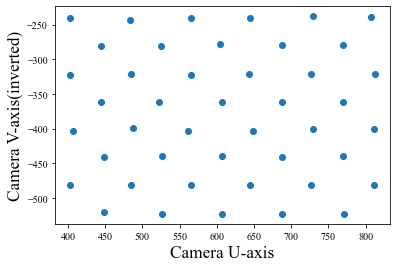

In [12]:
x_in, y_in, _ = zip(*cam_coord_0_0_m37)
x_in, y_in = np.array(x_in), np.array(y_in)
z = range(len(x_in))
fig, ax = plt.subplots()
# ax.set_title("Camera input Coordinates",fontproperties=font)
plt.scatter(x_in,-y_in)
plt.xlabel('Camera U-axis',fontproperties=font)
plt.ylabel('Camera V-axis(inverted)',fontproperties=font)
# plt.colorbar()
# plt.xticks()
# fig.savefig('.\\Camera_input_Coordinates.eps',format='eps')
plt.show()

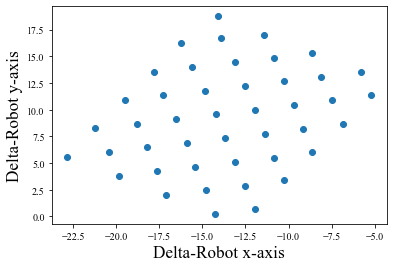

In [13]:
x_out , y_out, _ = zip(*robot_coord)
x_out , y_out = np.array(x_out), np.array(y_out)
z = range(len(x_out))
fig, ax = plt.subplots()
# ax.set_title('Delta-Robot Coordinates',fontproperties=font)
plt.scatter(x_out,y_out)
plt.xlabel('Delta-Robot x-axis',fontproperties=font)
plt.ylabel('Delta-Robot y-axis',fontproperties=font)
# fig.savefig('.\\Delta_Robot_Coordinates.eps',format='eps')
# plt.colorbar()
plt.show()

In [23]:
def R_T_mat_generator(input, output, DD):
    input = input[1:,:]
    output = output[1:,:]
    mean_centered_output = output - np.mean(output,axis=0)
    mean_centered_input = input - np.mean(input,axis=0)
    tr_mat_centered = np.dot(np.linalg.pinv(mean_centered_input),mean_centered_output)

    print('tr_mat:')
    print(tr_mat_centered)
    # np.save('R_mat',tr_mat_centered)
    U, S, Vt = np.linalg.svd(tr_mat_centered)

    # Extract rotation matrix
    R = np.dot(U, Vt)

    # Scaling matrix
    S_matrix = np.diag(S)

    print("Rotation matrix R:")
    print(R)
    # np.save('R_mat',R)

    print("Scaling matrix S:")
    print(S_matrix)

    print("Scaling matrix S multiplied by distance:")
    print(S_matrix/DD)

    theta = np.arccos(R[0, 0])
    angle_degrees = np.degrees(theta)
    print("Rotation angle in degrees:", angle_degrees)

    offset_found_Centered = np.mean(output - np.dot(input,tr_mat_centered),axis=0)
    # np.save('t_mat',offset_found_Centered)
    print('offset found:',offset_found_Centered)

    regenerated_output_centered = np.dot(input,tr_mat_centered) + offset_found_Centered

    differences = regenerated_output_centered - output
    x_differences , y_differences = differences[:,0],differences[:,1]
    distances = np.sqrt((x_differences**2)+(y_differences**2))
    print('max distance:',distances.max())
    print('mean distance:',distances.mean())
    print('min distance:',distances.min())
    print('median distance:',np.median(distances))

    fig, ax = plt.subplots()
    # ax.set_title('distances',fontproperties=font)
    plt.xlabel('samples',fontproperties=font)
    plt.ylabel('real vs predicted output distances per cm',fontproperties=font)
    plt.plot(distances)
    # fig.savefig('.\\distances.eps',format='eps')

    x_out_pred_centered_plot , y_out_pred_centered_plot = regenerated_output_centered[:,0],regenerated_output_centered[:,1]
    x_out , y_out = output[:,0],output[:,1]
    fig, ax = plt.subplots()
    # ax.set_title('Heatmap of Distance between \n predict using tr_mat centered and real Robot output',fontproperties=font)
    # plt.scatter(x_out, y_out, label='delta_xy')
    scat = plt.scatter(x_out_pred_centered_plot,y_out_pred_centered_plot,c=distances,cmap="hot")#, label = 'Camera Generated Coordinate'
    plt.xlabel('x-axis',fontproperties=font)
    plt.ylabel('y-axis',fontproperties=font)
    # plt.legend()
    plt.colorbar(scat,ax=ax)
    # fig.savefig('.\\Camera_Generated_Coordinate.eps',format='eps')
    plt.show()
    return R,S_matrix,S_matrix/DD,angle_degrees,offset_found_Centered , tr_mat_centered


tr_mat:
[[ 0.02083467  0.03272086  0.        ]
 [ 0.03556759 -0.02238839  0.        ]
 [ 0.          0.          0.        ]]
Rotation matrix R:
[[ 0.53481987  0.8449661   0.        ]
 [ 0.8449661  -0.53481987  0.        ]
 [ 0.          0.          1.        ]]
Scaling matrix S:
[[0.04203056 0.         0.        ]
 [0.         0.03878742 0.        ]
 [0.         0.         0.        ]]
Scaling matrix S multiplied by distance:
[[0.00175127 0.         0.        ]
 [0.         0.00161614 0.        ]
 [0.         0.         0.        ]]
Rotation angle in degrees: 57.66830363312415
offset found: [-39.76587848  -2.20838076 -61.        ]
max distance: 0.19132573644202847
mean distance: 0.09081085466301544
min distance: 0.011929338086157584
median distance: 0.07939653026740726


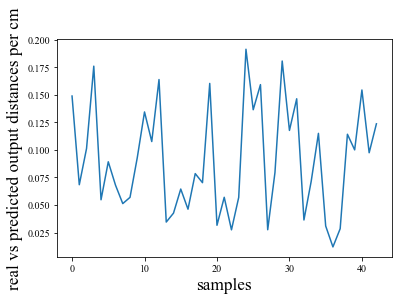

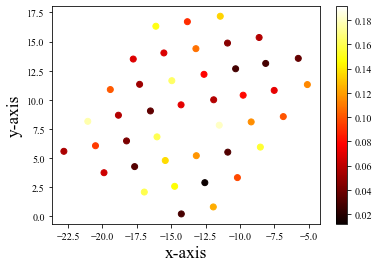

In [24]:
R_37, S_matrix_37, S_matrix_37_divided_by_distance, angle_degrees_37, offset_37, tr_mat_37 = R_T_mat_generator(cam_coord_0_0_m37, robot_coord, 61-37)

tr_mat:
[[ 0.0194263   0.03045654  0.        ]
 [ 0.03305294 -0.02059697  0.        ]
 [ 0.          0.          0.        ]]
Rotation matrix R:
[[ 0.53315492  0.84601763  0.        ]
 [ 0.84601763 -0.53315492  0.        ]
 [ 0.          0.          1.        ]]
Scaling matrix S:
[[0.03895843 0.         0.        ]
 [0.         0.03611032 0.        ]
 [0.         0.         0.        ]]
Scaling matrix S multiplied by distance:
[[0.00185516 0.         0.        ]
 [0.         0.00171954 0.        ]
 [0.         0.         0.        ]]
Rotation angle in degrees: 57.7811307754112
offset found: [-37.9986768   -1.48561737 -61.        ]
max distance: 0.16637629131743373
mean distance: 0.08984674716572082
min distance: 0.012738759348335354
median distance: 0.09406343104661949


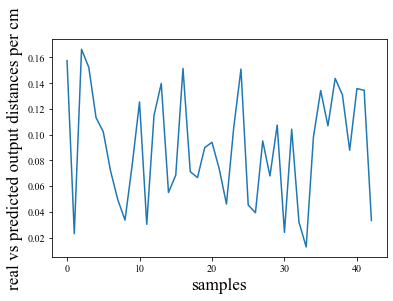

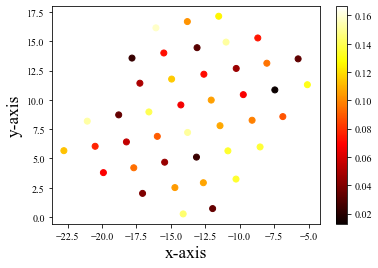

In [25]:
R_40, S_matrix_40, S_matrix_40_divided_by_distance, angle_degrees_40, offset_40, tr_mat_40 = R_T_mat_generator(cam_coord_0_0_m40, robot_coord, 61-40)

tr_mat:
[[ 0.01792488  0.02821028  0.        ]
 [ 0.03064639 -0.01914664  0.        ]
 [ 0.          0.          0.        ]]
Rotation matrix R:
[[ 0.53295353  0.84614451  0.        ]
 [ 0.84614451 -0.53295353  0.        ]
 [ 0.          0.          1.        ]]
Scaling matrix S:
[[0.03614198 0.         0.        ]
 [0.         0.03341667 0.        ]
 [0.         0.         0.        ]]
Scaling matrix S multiplied by distance:
[[0.00200789 0.         0.        ]
 [0.         0.00185648 0.        ]
 [0.         0.         0.        ]]
Rotation angle in degrees: 57.794768817310704
offset found: [-36.20584332  -0.67019441 -61.        ]
max distance: 0.19965649787852136
mean distance: 0.10255980175109788
min distance: 0.012413855180721842
median distance: 0.10559415932434278


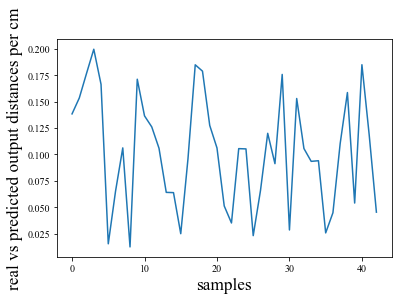

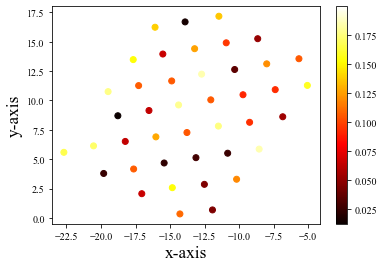

In [26]:
R_43, S_matrix_43, S_matrix_43_divided_by_distance, angle_degrees_43, offset_43, tr_mat_43 = R_T_mat_generator(cam_coord_0_0_m43, robot_coord, 61-43)

tr_mat:
[[ 0.01645831  0.02599037  0.        ]
 [ 0.02806442 -0.01767552  0.        ]
 [ 0.          0.          0.        ]]
Rotation matrix R:
[[ 0.53392547  0.84553154  0.        ]
 [ 0.84553154 -0.53392547  0.        ]
 [ 0.          0.          1.        ]]
Scaling matrix S:
[[0.0331674  0.         0.        ]
 [0.         0.03076256 0.        ]
 [0.         0.         0.        ]]
Scaling matrix S multiplied by distance:
[[0.00221116 0.         0.        ]
 [0.         0.00205084 0.        ]
 [0.         0.         0.        ]]
Rotation angle in degrees: 57.72893106683766
offset found: [-34.37563852   0.10628851 -61.        ]
max distance: 0.18555684243703244
mean distance: 0.0998940605453856
min distance: 0.02258165553949189
median distance: 0.09602068383924625


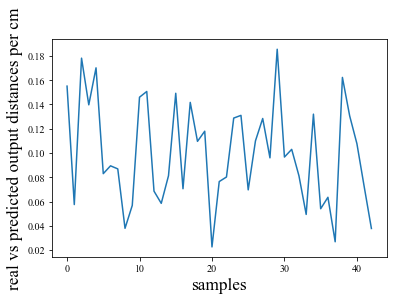

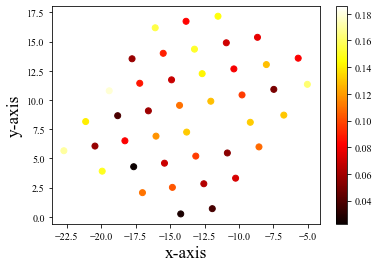

In [27]:
R_46, S_matrix_46, S_matrix_46_divided_by_distance, angle_degrees_46, offset_46, tr_mat_46 = R_T_mat_generator(cam_coord_0_0_m46, robot_coord, 61-46)

tr_mat:
[[ 0.01514441  0.02367332  0.        ]
 [ 0.02567067 -0.01617968  0.        ]
 [ 0.          0.          0.        ]]
Rotation matrix R:
[[ 0.53594204  0.84425478  0.        ]
 [ 0.84425478 -0.53594204  0.        ]
 [ 0.          0.          1.        ]]
Scaling matrix S:
[[0.03034825 0.         0.        ]
 [0.         0.02809855 0.        ]
 [0.         0.         0.        ]]
Scaling matrix S multiplied by distance:
[[0.00252902 0.         0.        ]
 [0.         0.00234155 0.        ]
 [0.         0.         0.        ]]
Rotation angle in degrees: 57.59217913101749
offset found: [-32.72073136   0.91294341 -61.        ]
max distance: 0.20518590574930537
mean distance: 0.08891919668293413
min distance: 0.003972762399877372
median distance: 0.08582319183902282


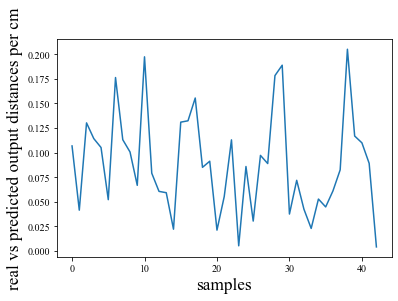

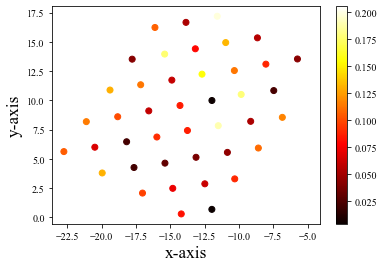

In [28]:
R_49, S_matrix_49, S_matrix_49_divided_by_distance, angle_degrees_49, offset_49, tr_mat_49 = R_T_mat_generator(cam_coord_0_0_m49, robot_coord, 61-49)

tr_mat:
[[ 0.01373153  0.02161329  0.        ]
 [ 0.02336734 -0.01468066  0.        ]
 [ 0.          0.          0.        ]]
Rotation matrix R:
[[ 0.53403837  0.84546024  0.        ]
 [ 0.84546024 -0.53403837  0.        ]
 [ 0.          0.          1.        ]]
Scaling matrix S:
[[0.02759845 0.         0.        ]
 [0.         0.02560408 0.        ]
 [0.         0.         0.        ]]
Scaling matrix S multiplied by distance:
[[0.00306649 0.         0.        ]
 [0.         0.0028449  0.        ]
 [0.         0.         0.        ]]
Rotation angle in degrees: 57.72128031997719
offset found: [-31.03156335   1.54006207 -61.        ]
max distance: 0.23958475504398458
mean distance: 0.08703739361875343
min distance: 0.01679175251775259
median distance: 0.07559547480132346


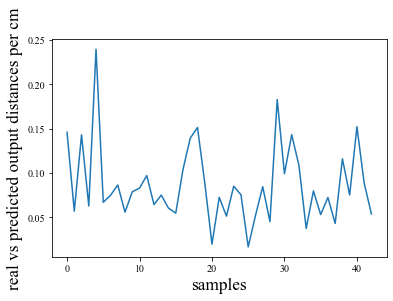

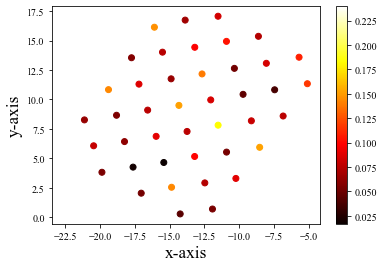

In [29]:
R_52, S_matrix_52, S_matrix_52_divided_by_distance, angle_degrees_52, offset_52, tr_mat_52 = R_T_mat_generator(cam_coord_0_0_m52, robot_coord, 61-52)

tr_mat:
[[ 0.01237019  0.01943458  0.        ]
 [ 0.02107493 -0.01318109  0.        ]
 [ 0.          0.          0.        ]]
Rotation matrix R:
[[ 0.53349044  0.8458061   0.        ]
 [ 0.8458061  -0.53349044  0.        ]
 [ 0.          0.          1.        ]]
Scaling matrix S:
[[0.02486219 0.         0.        ]
 [0.         0.02303236 0.        ]
 [0.         0.         0.        ]]
Scaling matrix S multiplied by distance:
[[0.0041437  0.         0.        ]
 [0.         0.00383873 0.        ]
 [0.         0.         0.        ]]
Rotation angle in degrees: 57.75840547934689
offset found: [-29.37642436   2.23529008 -61.        ]
max distance: 0.2036032578418536
mean distance: 0.08032825739926418
min distance: 0.017462498812997662
median distance: 0.07195269370603645


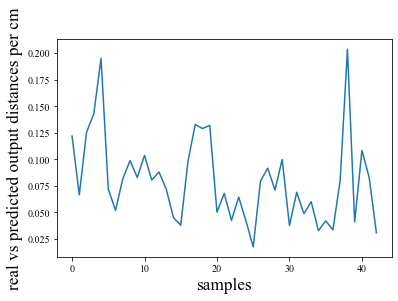

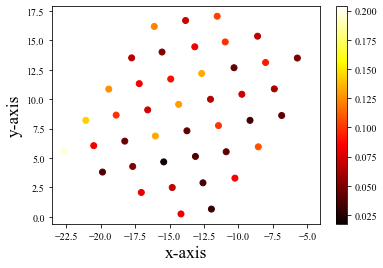

In [30]:
R_55, S_matrix_55, S_matrix_55_divided_by_distance, angle_degrees_55, offset_55, tr_mat_55 = R_T_mat_generator(cam_coord_0_0_m55, robot_coord, 61-55)

tr_mat:
[[ 0.01106288  0.01734001  0.        ]
 [ 0.01879241 -0.0117681   0.        ]
 [ 0.          0.          0.        ]]
Rotation matrix R:
[[ 0.53416861  0.84537796  0.        ]
 [ 0.84537796 -0.53416861  0.        ]
 [ 0.          0.          1.        ]]
Scaling matrix S:
[[0.02217785 0.         0.        ]
 [0.         0.0205633  0.        ]
 [0.         0.         0.        ]]
Scaling matrix S multiplied by distance:
[[0.00739262 0.         0.        ]
 [0.         0.00685443 0.        ]
 [0.         0.         0.        ]]
Rotation angle in degrees: 57.712454075697536
offset found: [-27.74641867   2.88987152 -61.        ]
max distance: 0.21185752318164985
mean distance: 0.08610119326710215
min distance: 0.02014243595548719
median distance: 0.08460331279862447


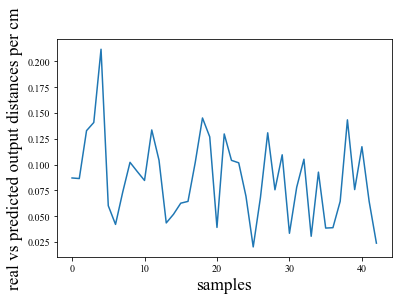

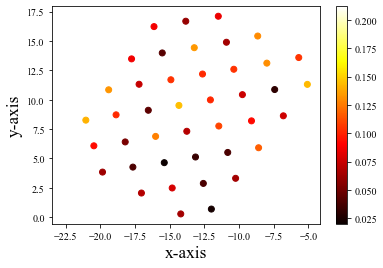

In [31]:
R_58, S_matrix_58, S_matrix_58_divided_by_distance, angle_degrees_58, offset_58, tr_mat_58 = R_T_mat_generator(cam_coord_0_0_m58, robot_coord, 61-58)

tr_mat:
[[ 0.0097236   0.0152245   0.        ]
 [ 0.01660256 -0.01038788  0.        ]
 [ 0.          0.          0.        ]]
Rotation matrix R:
[[ 0.53418626  0.84536681  0.        ]
 [ 0.84536681 -0.53418626  0.        ]
 [ 0.          0.          1.        ]]
Scaling matrix S:
[[0.01958931 0.         0.        ]
 [0.         0.0180595  0.        ]
 [0.         0.         0.        ]]
Scaling matrix S multiplied by distance:
[[0.19589311 0.         0.        ]
 [0.         0.18059504 0.        ]
 [0.         0.         0.        ]]
Rotation angle in degrees: 57.71125787785452
offset found: [-26.11843787   3.57679953 -61.        ]
max distance: 0.19770426502098196
mean distance: 0.0919063468772825
min distance: 0.005915641420246686
median distance: 0.09063571127803198


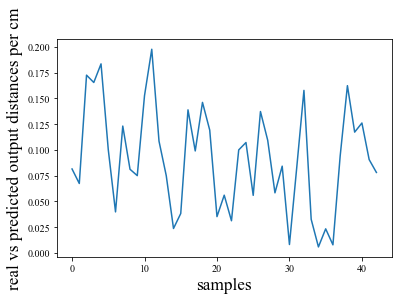

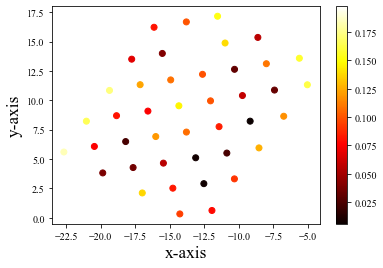

In [32]:
R_61, S_matrix_61, S_matrix_61_divided_by_distance, angle_degrees_61, offset_61, tr_mat_61 = R_T_mat_generator(cam_coord_0_0_m61, robot_coord, 61.1-61)

In [33]:
print('angles:','\n37:',angle_degrees_37,',','\n40:',angle_degrees_40,',','\n43:',angle_degrees_43,',','\n46:',angle_degrees_46,',','\n49:',angle_degrees_49,',')

angles: 
37: 57.66830363312415 , 
40: 57.7811307754112 , 
43: 57.794768817310704 , 
46: 57.72893106683766 , 
49: 57.59217913101749 ,


In [34]:
print('offsets:','\n37:',offset_37,',','\n40:',offset_40,',','\n43:',offset_43,',','\n46:',offset_46,',','\n49:',offset_49,',')

offsets: 
37: [-39.76587848  -2.20838076 -61.        ] , 
40: [-37.9986768   -1.48561737 -61.        ] , 
43: [-36.20584332  -0.67019441 -61.        ] , 
46: [-34.37563852   0.10628851 -61.        ] , 
49: [-32.72073136   0.91294341 -61.        ] ,


In [35]:
print('R_mats:','\n37:\n',R_37,',','\n40:\n',R_40,',','\n43:\n',R_43,',','\n46:\n',R_46,',','\n49:\n',R_49)

R_mats: 
37:
 [[ 0.53481987  0.8449661   0.        ]
 [ 0.8449661  -0.53481987  0.        ]
 [ 0.          0.          1.        ]] , 
40:
 [[ 0.53315492  0.84601763  0.        ]
 [ 0.84601763 -0.53315492  0.        ]
 [ 0.          0.          1.        ]] , 
43:
 [[ 0.53295353  0.84614451  0.        ]
 [ 0.84614451 -0.53295353  0.        ]
 [ 0.          0.          1.        ]] , 
46:
 [[ 0.53392547  0.84553154  0.        ]
 [ 0.84553154 -0.53392547  0.        ]
 [ 0.          0.          1.        ]] , 
49:
 [[ 0.53594204  0.84425478  0.        ]
 [ 0.84425478 -0.53594204  0.        ]
 [ 0.          0.          1.        ]]


In [36]:
print('S_mats:','\n37:\n',S_matrix_37,',','\n40:\n',S_matrix_40,',','\n43:\n',S_matrix_43,',','\n46:\n',S_matrix_46,',','\n49:\n',S_matrix_49)

S_mats: 
37:
 [[0.04203056 0.         0.        ]
 [0.         0.03878742 0.        ]
 [0.         0.         0.        ]] , 
40:
 [[0.03895843 0.         0.        ]
 [0.         0.03611032 0.        ]
 [0.         0.         0.        ]] , 
43:
 [[0.03614198 0.         0.        ]
 [0.         0.03341667 0.        ]
 [0.         0.         0.        ]] , 
46:
 [[0.0331674  0.         0.        ]
 [0.         0.03076256 0.        ]
 [0.         0.         0.        ]] , 
49:
 [[0.03034825 0.         0.        ]
 [0.         0.02809855 0.        ]
 [0.         0.         0.        ]]


In [37]:
print('S_mats divided by distance:','\n37:\n',S_matrix_37_divided_by_distance,',','\n40:\n',S_matrix_40_divided_by_distance,',','\n43:\n',S_matrix_43_divided_by_distance,',','\n46:\n',S_matrix_46_divided_by_distance,',','\n49:\n',S_matrix_49_divided_by_distance)

S_mats divided by distance: 
37:
 [[0.00175127 0.         0.        ]
 [0.         0.00161614 0.        ]
 [0.         0.         0.        ]] , 
40:
 [[0.00185516 0.         0.        ]
 [0.         0.00171954 0.        ]
 [0.         0.         0.        ]] , 
43:
 [[0.00200789 0.         0.        ]
 [0.         0.00185648 0.        ]
 [0.         0.         0.        ]] , 
46:
 [[0.00221116 0.         0.        ]
 [0.         0.00205084 0.        ]
 [0.         0.         0.        ]] , 
49:
 [[0.00252902 0.         0.        ]
 [0.         0.00234155 0.        ]
 [0.         0.         0.        ]]


In [38]:
angle_degrees_37,angle_degrees_40,angle_degrees_43,angle_degrees_46,angle_degrees_49


(57.66830363312415,
 57.7811307754112,
 57.794768817310704,
 57.72893106683766,
 57.59217913101749)

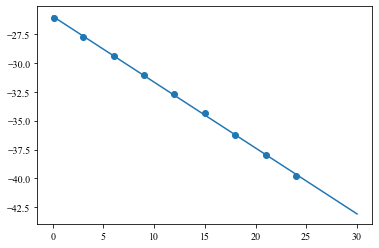

In [39]:
# off_out0 = np.array([offset_37[0],offset_40[0],offset_43[0],offset_46[0],offset_49[0]])
# off_in0 = np.array([50, 47, 44, 41, 38])

off_out0 = np.array([offset_37[0],
                     offset_40[0],
                     offset_43[0],
                     offset_46[0],
                     offset_49[0],
                     offset_52[0],
                     offset_55[0],
                     offset_58[0],
                     offset_61[0]])
off_in0 = np.array(([61-37, 61-40, 61-43, 61-46, 61-49, 61-52, 61-55, 61-58, 61.1-61]))

Values_off0 = np.polyfit(off_in0, off_out0, deg= 1)
p_off0 = np.poly1d(Values_off0)
x_linespace1 = np.linspace(0,30,int(30 - 0))#np.linspace(S0_in.min(),S0_in.max(),int(S0_in.max() - S0_in.min()))
y_est_off0 = p_off0(x_linespace1)

plt.plot(x_linespace1,y_est_off0)
plt.scatter(off_in0,off_out0)


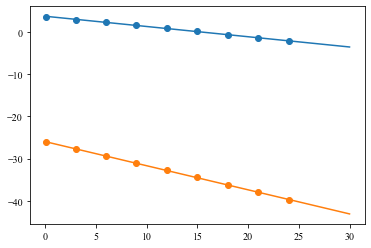

In [40]:
off_out1 = np.array([offset_37[1],
                     offset_40[1],
                     offset_43[1],
                     offset_46[1],
                     offset_49[1],
                     offset_52[1],
                     offset_55[1],
                     offset_58[1],
                     offset_61[1]])
off_in1 = np.array(([61-37, 61-40, 61-43, 61-46, 61-49, 61-52, 61-55, 61-58, 61.1-61]))

Values_off1 = np.polyfit(off_in1, off_out1, deg= 1)
p_off1 = np.poly1d(Values_off1)
x_linespace1 = np.linspace(0,30,int(30 - 0))#np.linspace(S0_in.min(),S0_in.max(),int(S0_in.max() - S0_in.min()))
y_est_off1 = p_off1(x_linespace1)

plt.plot(x_linespace1,y_est_off1)
plt.scatter(off_in1,off_out1)

plt.plot(x_linespace1,y_est_off0)
plt.scatter(off_in0,off_out0)


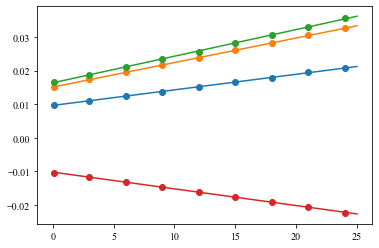

In [41]:
tr00_out = np.array([tr_mat_37[0,0],
                     tr_mat_40[0,0],
                     tr_mat_43[0,0],
                     tr_mat_46[0,0],
                     tr_mat_49[0,0],
                     tr_mat_52[0,0],
                     tr_mat_55[0,0],
                     tr_mat_58[0,0],
                     tr_mat_61[0,0]])
tr00_in = np.array(([61-37, 61-40, 61-43, 61-46, 61-49, 61-52, 61-55, 61-58, 61.1-61]))

Values_tr00 = np.polyfit(tr00_in, tr00_out, deg= 1)
p00 = np.poly1d(Values_tr00)
x_linespace1 = np.linspace(0,25,int(25 - 0))#np.linspace(S0_in.min(),S0_in.max(),int(S0_in.max() - S0_in.min()))
y_est00 = p00(x_linespace1)

plt.plot(x_linespace1,y_est00)
plt.scatter(tr00_in,tr00_out)



tr01_out = np.array([tr_mat_37[0,1],
                     tr_mat_40[0,1],
                     tr_mat_43[0,1],
                     tr_mat_46[0,1],
                     tr_mat_49[0,1],
                     tr_mat_52[0,1],
                     tr_mat_55[0,1],
                     tr_mat_58[0,1],
                     tr_mat_61[0,1]])
tr01_in = np.array(([61-37, 61-40, 61-43, 61-46, 61-49, 61-52, 61-55, 61-58, 61.1-61]))

Values_tr01 = np.polyfit(tr01_in, tr01_out, deg= 1)
p01 = np.poly1d(Values_tr01)
x_linespace1 = np.linspace(0,25,int(25 - 0))#np.linspace(S0_in.min(),S0_in.max(),int(S0_in.max() - S0_in.min()))
y_est01 = p01(x_linespace1)

plt.plot(x_linespace1,y_est01)
plt.scatter(tr01_in,tr01_out)



tr10_out = np.array([tr_mat_37[1,0],
                     tr_mat_40[1,0],
                     tr_mat_43[1,0],
                     tr_mat_46[1,0],
                     tr_mat_49[1,0],
                     tr_mat_52[1,0],
                     tr_mat_55[1,0],
                     tr_mat_58[1,0],
                     tr_mat_61[1,0]])
tr10_in = np.array(([61-37, 61-40, 61-43, 61-46, 61-49, 61-52, 61-55, 61-58, 61.1-61]))

Values_tr10 = np.polyfit(tr10_in, tr10_out, deg= 1)
p10 = np.poly1d(Values_tr10)
x_linespace1 = np.linspace(0,25,int(25 - 0))#np.linspace(S0_in.min(),S0_in.max(),int(S0_in.max() - S0_in.min()))
y_est10 = p10(x_linespace1)

plt.plot(x_linespace1,y_est10)
plt.scatter(tr10_in,tr10_out)



# tr11_out = np.array([tr_mat_37[1,1],tr_mat_40[1,1],tr_mat_43[1,1],tr_mat_46[1,1],tr_mat_49[1,1]])
# tr11_in = np.array([50, 47, 44, 41, 38])

tr11_out = np.array([tr_mat_37[1,1],
                     tr_mat_40[1,1],
                     tr_mat_43[1,1],
                     tr_mat_46[1,1],
                     tr_mat_49[1,1],
                     tr_mat_52[1,1],
                     tr_mat_55[1,1],
                     tr_mat_58[1,1],
                     tr_mat_61[1,1]])
tr11_in = np.array(([61-37, 61-40, 61-43, 61-46, 61-49, 61-52, 61-55, 61-58, 61.1-61]))

Values_tr11 = np.polyfit(tr11_in, tr11_out, deg= 1)
p11 = np.poly1d(Values_tr11)
x_linespace1 = np.linspace(0,25,int(25 - 0))#np.linspace(S0_in.min(),S0_in.max(),int(S0_in.max() - S0_in.min()))
y_est11 = p11(x_linespace1)

plt.plot(x_linespace1,y_est11)
plt.scatter(tr11_in,tr11_out)


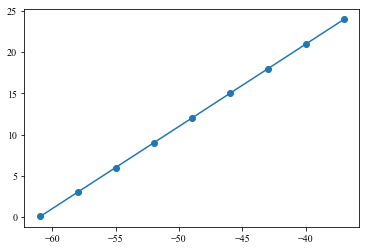

In [42]:
H_out = np.array(([61-37, 61-40, 61-43, 61-46, 61-49, 61-52, 61-55, 61-58, 61.1-61]))
H_in = np.array(([-37, -40, -43, -46, -49, -52, -55, -58, -61]))

Value_H = np.polyfit(H_in, H_out, deg= 1)
pH = np.poly1d(Value_H)
x_linespace1 = np.linspace(-61,-37,int(-37 - (-61)))#np.linspace(S0_in.min(),S0_in.max(),int(S0_in.max() - S0_in.min()))
y_est01 = pH(x_linespace1)

plt.plot(x_linespace1,y_est01)
plt.scatter(H_in,H_out)



In [43]:
Values_tr00,Values_tr01,Values_tr10,Values_tr11

(array([0.00046421, 0.00961058]),
 array([0.00073088, 0.01507284]),
 array([0.00079336, 0.01634187]),
 array([-0.00049787, -0.01024278]))

In [44]:
Values_off0,Values_off1

(array([ -0.56989133, -25.97048449]), array([-0.24228533,  3.67645627]))

In [45]:
Value_H

array([ 0.99777778, 60.90222222])

In [46]:
H = 61-37

p00,p01,p10,p11 = np.poly1d(Values_tr00),np.poly1d(Values_tr01),np.poly1d(Values_tr10),np.poly1d(Values_tr11)
tr_Hight = np.array([[p00(H),p01(H),0],[p10(H),p11(H),0],[0,0,0]])

In [47]:
tr_mat_37

array([[ 0.02083467,  0.03272086,  0.        ],
       [ 0.03556759, -0.02238839,  0.        ],
       [ 0.        ,  0.        ,  0.        ]])

In [48]:
tr_Hight

array([[ 0.02075173,  0.03261397,  0.        ],
       [ 0.03538255, -0.0221917 ,  0.        ],
       [ 0.        ,  0.        ,  0.        ]])

In [49]:
values = [Values_tr00,Values_tr01,Values_tr10,Values_tr11,Values_off0,Values_off1]
np.save('values.npy',values)
values

[array([0.00046421, 0.00961058]),
 array([0.00073088, 0.01507284]),
 array([0.00079336, 0.01634187]),
 array([-0.00049787, -0.01024278]),
 array([ -0.56989133, -25.97048449]),
 array([-0.24228533,  3.67645627])]

In [143]:
Values_tr00,Values_tr01,Values_tr10,Values_tr11,Values_off0,Values_off1 = np.load('values.npy')
Values_off1

array([-0.23674144,  9.69259999])